# Impact of Error Types on Decoder Performance
### Isolated-Error Analysis for Composite DNA Decoding
### Error models: EZ17, G15, O17 — Alphabet $\mathcal{A}_{11}$ (15 classes) — Coverage $M=10$

This notebook measures how each decoder behaves when **only one error type is
active at a time** (substitutions only, insertions only, deletions only, long
deletions only, or all errors). For each (error model, error mode) it
synthesises a fresh evaluation set and evaluates the four decoders.

---

## ⚠️ This notebook contained the data-generation bug — it is now fixed

The old `apply_ids_noise` used **three independent per-base coins**
(delete → insert → substitute, each with a raw per-base rate). That is **not**
the model used by the DNAformer / Bar-Lev Synthetic Data Generator, and it is
the source of the wrong error profiles.

This notebook replaces it with the **corrected two-stage injector**, copied to
match `dataset_generator_uniform_composite.py::apply_ids_noise` (cross-checked
against `other_github_dataset`, i.e. the DNAformer github simulator):

> **Stage 1** — one outer *error vs. no-error* coin per base, using the
> **general** rates `s + i + d + ld`.
> **Stage 2** — conditional on an error, the event type is drawn with
> **per-base weights** over `{s, pi, d, ld}` (note: the `'i'` per-base entry is
> a *which-base-to-insert* weight, **not** an event probability — the event
> probability of an insertion is `pi`).
> On an insertion the inserted base is emitted **before** the original base and
> the original base is then consumed unchanged. Long deletions (`ld`) remove a
> run of length 2–6 drawn from `LONG_DELETION_LENGTH_RATES`.

Consequences for this notebook:

| Aspect | Old (buggy) | This notebook (fixed) |
|---|---|---|
| Noise model | 3 independent coins | 2-stage (general coin → per-base event weights) |
| Long deletions | absent | present (`ld`, length 2–6) |
| Insertion event prob. | per-base `i` | per-base `pi` (per-base `i` is insert-base weight) |
| Error modes | sub / ins / del / all | sub / ins / del / **long-del** / all |
| Results directory | `./results_{name}_{alphabet}` | `./Results/{name}_{alphabet_mode}_H{H}_L{L}_lr{lr}_eps{eps}_seed{SEED}` |
| Weights file | `best_model_{name}_{alphabet}_M{M}.pth` | `best_model_M{M}.pth` |
| KL/ML epsilon | hard-coded `0.01` | per-profile `best_eps_klml` (EZ17/O17 → 0.01, G15 → 0.05) |

Trained weights are loaded from the new `./Results/...` directories produced
by the re-run `train_evaluate_uniform_composite.py`. Each (error model, error
mode) experiment is re-seeded from `SEED=42` so the synthesised evaluation set
is reproducible.


## Cell 1 — Device configuration

In [1]:
# =============================================================================
# CELL 1: DEVICE CONFIGURATION
# =============================================================================
import os

# Pin GPU if needed (set to "" to let PyTorch choose)
DEVICE_ID = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = DEVICE_ID

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
   GPU: NVIDIA GeForce RTX 3080


## Cell 2 — Imports

In [2]:
# =============================================================================
# CELL 2: IMPORTS
# =============================================================================
import random
import pickle
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("Imports ready.")

Imports ready.


## Cell 3 — Configuration

`results_dir` is built per error model with the **exact** formula that
`train_evaluate_uniform_composite.py::make_config_for_profile` uses for its
`subdir`, so the weights are found automatically.

Note `best_eps_klml` is per-profile (EZ17 → 0.01, G15 → 0.05, O17 → 0.01) and
appears **both** in the results-directory name **and** in the KL/ML decoders,
exactly as in the training pipeline's `auto` epsilon mode.


In [3]:
# =============================================================================
# CELL 3: CONFIGURATION
# =============================================================================

# ------------------- ANALYSIS TARGET -------------------
ALPHABET_MODE = "2mix_3mix_4mix"     # A_11 alphabet (15 classes)
COVERAGE_M    = 10                   # coverage depth for this analysis

# Error models to analyse (canonical names resolved below)
ERROR_MODELS_TO_ANALYZE = ["erlich", "grass", "organick"]

# ------------------- TRAINING HYPERPARAMETERS (results dir depends on these) ----
HIDDEN_DIM    = 128
NUM_LAYERS    = 2
DROPOUT       = 0.2
BIDIRECTIONAL = True
BATCH_SIZE    = 500
LEARNING_RATE = 1e-3
SEED          = 42

RESULTS_ROOT  = "./Results"

# ------------------- EVALUATION-SET SIZE -------------------
NUM_SAMPLES_EVAL = 20000             # synthetic samples generated per experiment

# ------------------- ERROR-MODEL SPECS -------------------
# best_eps_klml: per-profile KL/ML smoothing epsilon used by the training
# pipeline's auto mode. Mirrored here so (a) the results dir matches and
# (b) the baseline decoders use the identical epsilon.
ERROR_MODEL_SPECS = {
    "EZ17":     {"seq_length": 136, "name": "EZ17", "best_eps_klml": 0.01},
    "G15":      {"seq_length": 104, "name": "G15",  "best_eps_klml": 0.05},
    "O17":      {"seq_length": 77,  "name": "O17",  "best_eps_klml": 0.01},
    # backwards-compat aliases
    "erlich":   {"seq_length": 136, "name": "EZ17", "best_eps_klml": 0.01},
    "grass":    {"seq_length": 104, "name": "G15",  "best_eps_klml": 0.05},
    "organick": {"seq_length": 77,  "name": "O17",  "best_eps_klml": 0.01},
}

VOCAB_SIZES = {"2mix_only": 10, "2mix_3mix": 14, "2mix_3mix_4mix": 15}
assert ALPHABET_MODE in VOCAB_SIZES, f"Unknown ALPHABET_MODE: {ALPHABET_MODE}"

# ----- Per-error-model results sub-directory (matches the training script) -----
def make_results_dir(error_model):
    """Build the Results sub-directory for a given error model, using the
    IDENTICAL formula as train_evaluate_uniform_composite.py."""
    specs = ERROR_MODEL_SPECS[error_model]
    eps = specs['best_eps_klml']
    subdir = (f"{specs['name']}_{ALPHABET_MODE}"
              f"_H{HIDDEN_DIM}_L{NUM_LAYERS}_lr{LEARNING_RATE:.0e}"
              f"_eps{eps:g}_seed{SEED}")
    return os.path.join(RESULTS_ROOT, subdir)

# ------------------- BASE CONFIG -------------------
BASE_CONFIG = {
    "alphabet_mode":    ALPHABET_MODE,
    "vocab_size":       VOCAB_SIZES[ALPHABET_MODE],
    "coverage_M":       COVERAGE_M,
    "num_samples_eval": NUM_SAMPLES_EVAL,
    # model architecture (must match trained model)
    "input_channels":   4,
    "hidden_dim":       HIDDEN_DIM,
    "num_layers":       NUM_LAYERS,
    "dropout":          DROPOUT,
    "bidirectional":    BIDIRECTIONAL,
    "batch_size":       BATCH_SIZE,
    "seed":             SEED,
}

OUTPUT_DIR = os.path.join(
    "./isolated_error_analysis",
    f"{ALPHABET_MODE}_H{HIDDEN_DIM}_L{NUM_LAYERS}_lr{LEARNING_RATE:.0e}"
    f"_seed{SEED}_M{COVERAGE_M}")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 64)
print(" ISOLATED ERROR-TYPE ANALYSIS CONFIGURATION")
print("=" * 64)
print(f"   Alphabet        : {ALPHABET_MODE} ({BASE_CONFIG['vocab_size']} classes)")
print(f"   Coverage depth  : {COVERAGE_M}")
print(f"   Error models    : {[ERROR_MODEL_SPECS[m]['name'] for m in ERROR_MODELS_TO_ANALYZE]}")
print(f"   Eval samples    : {NUM_SAMPLES_EVAL:,} per experiment")
print(f"   Output dir      : {OUTPUT_DIR}")
print(f"   Planned weight dirs:")
for m in ERROR_MODELS_TO_ANALYZE:
    print(f"     - {ERROR_MODEL_SPECS[m]['name']:<6} -> {make_results_dir(m)}")
print("=" * 64)

 ISOLATED ERROR-TYPE ANALYSIS CONFIGURATION
   Alphabet        : 2mix_3mix_4mix (15 classes)
   Coverage depth  : 10
   Error models    : ['EZ17', 'G15', 'O17']
   Eval samples    : 20,000 per experiment
   Output dir      : ./isolated_error_analysis/2mix_3mix_4mix_H128_L2_lr1e-03_seed42_M10
   Planned weight dirs:
     - EZ17   -> ./Results/EZ17_2mix_3mix_4mix_H128_L2_lr1e-03_eps0.01_seed42
     - G15    -> ./Results/G15_2mix_3mix_4mix_H128_L2_lr1e-03_eps0.05_seed42
     - O17    -> ./Results/O17_2mix_3mix_4mix_H128_L2_lr1e-03_eps0.01_seed42


## Cell 4 — Seed & reproducibility

In [4]:
# =============================================================================
# CELL 4: SEED & REPRODUCIBILITY
# =============================================================================
def set_seed(seed):
    """Seed Python random, numpy and torch (CPU+CUDA). Disables non-determinism."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(BASE_CONFIG['seed'])
print(f"Random seed set to {BASE_CONFIG['seed']}.")

Random seed set to 42.


## Cell 5 — Symbol mappings & ideal vectors

In [5]:
# =============================================================================
# CELL 5: SYMBOL MAPPINGS & IDEAL VECTORS
# =============================================================================
def build_symbol_to_idx(mode):
    s = {'A': 0, 'C': 1, 'G': 2, 'T': 3,
         'M1': 4, 'M2': 5, 'M3': 6, 'M4': 7, 'M5': 8, 'M6': 9}
    if mode in ("2mix_3mix", "2mix_3mix_4mix"):
        s.update({'T1': 10, 'T2': 11, 'T3': 12, 'T4': 13})
    if mode == "2mix_3mix_4mix":
        s.update({'Q1': 14})
    return s


def build_ideal_vectors(mode):
    vecs = [
        [1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 1.0],
        [0.5, 0.0, 0.0, 0.5], [0.0, 0.5, 0.5, 0.0],
        [0.0, 0.5, 0.0, 0.5], [0.0, 0.0, 0.5, 0.5],
        [0.5, 0.5, 0.0, 0.0], [0.5, 0.0, 0.5, 0.0],
    ]
    if mode in ("2mix_3mix", "2mix_3mix_4mix"):
        t = 1.0 / 3.0
        vecs += [[t, t, t, 0.0], [t, t, 0.0, t], [t, 0.0, t, t], [0.0, t, t, t]]
    if mode == "2mix_3mix_4mix":
        vecs.append([0.25, 0.25, 0.25, 0.25])
    return torch.tensor(vecs, dtype=torch.float32)


SYMBOL_TO_IDX = build_symbol_to_idx(BASE_CONFIG["alphabet_mode"])
IDX_TO_SYMBOL = {v: k for k, v in SYMBOL_TO_IDX.items()}
IDEAL_VECTORS = build_ideal_vectors(BASE_CONFIG["alphabet_mode"]).to(device)

print(f"Symbol mappings: {len(SYMBOL_TO_IDX)} symbols.")

Symbol mappings: 15 symbols.


## Cell 6 — Composite alphabet definitions

In [6]:
# =============================================================================
# CELL 6: COMPOSITE ALPHABET DEFINITIONS
# =============================================================================
PURE_BASES = {'A': ['A'], 'C': ['C'], 'G': ['G'], 'T': ['T']}

TWO_MIX_MAP = {
    'M1': ['A', 'T'], 'M2': ['C', 'G'], 'M3': ['C', 'T'],
    'M4': ['G', 'T'], 'M5': ['A', 'C'], 'M6': ['A', 'G'],
}

THREE_MIX_MAP = {
    'T1': ['A', 'C', 'G'], 'T2': ['A', 'C', 'T'],
    'T3': ['A', 'G', 'T'], 'T4': ['C', 'G', 'T'],
}

FOUR_MIX_MAP = {'Q1': ['A', 'C', 'G', 'T']}


def build_composite_map(mode):
    """Composite-symbol -> constituent-nucleotides map for the alphabet mode."""
    cmap = dict(PURE_BASES)
    cmap.update(TWO_MIX_MAP)
    if mode in ("2mix_3mix", "2mix_3mix_4mix"):
        cmap.update(THREE_MIX_MAP)
    if mode == "2mix_3mix_4mix":
        cmap.update(FOUR_MIX_MAP)
    return cmap


COMPOSITE_MAP = build_composite_map(BASE_CONFIG["alphabet_mode"])
ALL_SYMBOLS = list(COMPOSITE_MAP.keys())
print(f"Composite alphabet: {len(ALL_SYMBOLS)} symbols.")

Composite alphabet: 15 symbols.


## Cell 7 — Error-rate class with isolated-error support

**This replaces the buggy `ErrorRatesIsolated`.** The error-rate *values* are
transcribed verbatim from `dataset_generator_uniform_composite.py` (which in
turn matches `other_github_dataset`). Storage convention per base:

- `s`  — substitution probability
- `i`  — *which-base-to-insert* weight (used only to pick the inserted symbol)
- `pi` — pre-insertion probability = **event** probability of an insertion
- `d`  — single-base deletion probability
- `ld` — long-deletion event probability (length drawn from `LONG_DELETION_LENGTH_RATES`)

The isolated-error modes now zero out the relevant entries of **both** the
general rates (Stage 1 coin) **and** the per-base event weights (Stage 2),
and there is a new `long_deletion_only` mode because `ld` is a real event type
in the corrected model.


In [7]:
# =============================================================================
# CELL 7: ERROR-RATE CLASS WITH ISOLATED-ERROR SUPPORT
#         (values + structure match dataset_generator_uniform_composite.py)
# =============================================================================
class ErrorRatesIsolated:
    """Error-rate configuration supporting isolated error types.

    error_mode is one of:
        'all'                - every error type active (true profile)
        'substitution_only'  - only substitutions
        'insertion_only'     - only insertions
        'deletion_only'      - only single-base deletions
        'long_deletion_only' - only long deletions
    """

    # Long-deletion length distribution (from the github ClusterGenerator).
    LONG_DELETION_LENGTH_RATES = {
        2: 2.8e-4,
        3: 7.75e-5,
        4: 3.25e-5,
        5: 1.0e-6,
        6: 5.5e-8,
    }

    def __init__(self, error_mode="all"):
        self.error_mode = error_mode
        self.profile_name = None
        self.general_errors = {'s': 0.0, 'i': 0.0, 'd': 0.0, 'ld': 0.0}
        self.per_base_errors = {
            b: {'s': 0.0, 'i': 0.0, 'pi': 0.0, 'd': 0.0, 'ld': 0.0}
            for b in 'ACGT'
        }
        self.long_deletion_length_rates = dict(self.LONG_DELETION_LENGTH_RATES)

    # ------------------------------------------------------------------
    def _apply_error_mode(self, base_general, base_per_base):
        """Filter the full base rates down to the active error mode.

        The corrected two-stage model uses the GENERAL rates for the Stage-1
        error coin and the PER-BASE {s, pi, d, ld} weights for the Stage-2
        event-type draw, so BOTH must be filtered consistently.
        Note: per-base 'i' (insert-base weight) is preserved whenever
        insertions are active, because it only selects WHICH base to insert.
        """
        # Which general / event keys survive in each mode.
        keep = {
            'all':                {'s', 'i', 'd', 'ld'},
            'substitution_only':  {'s'},
            'insertion_only':     {'i'},
            'deletion_only':      {'d'},
            'long_deletion_only': {'ld'},
        }
        if self.error_mode not in keep:
            raise ValueError(f"Unknown error_mode: {self.error_mode}")
        active = keep[self.error_mode]

        # General rates: keep only active keys (Stage-1 coin sums these).
        self.general_errors = {
            k: (base_general[k] if k in active else 0.0)
            for k in ('s', 'i', 'd', 'ld')
        }

        # Per-base event weights.
        self.per_base_errors = {}
        for b in 'ACGT':
            src = base_per_base[b]
            # 'pi' is the insertion EVENT weight; gate it on insertions.
            pi = src.get('pi', src['i']) if 'i' in active else 0.0
            # 'i' is the insert-base SELECTION weight; keep it whenever
            # insertions are active so the inserted base is drawn correctly.
            i_weight = src['i'] if 'i' in active else 0.0
            self.per_base_errors[b] = {
                's':  src['s']  if 's'  in active else 0.0,
                'i':  i_weight,
                'pi': pi,
                'd':  src['d']  if 'd'  in active else 0.0,
                'ld': src['ld'] if 'ld' in active else 0.0,
            }

    # ------------------------------------------------------------------
    # Profiles -- values verbatim from dataset_generator_uniform_composite.py
    # ------------------------------------------------------------------
    def set_EZ17_values(self):
        """Erlich & Zielinski 2017 (Illumina miSeq + Twist Bioscience)."""
        self.profile_name = "EZ17"
        base_general = {'s': 1.32e-03, 'i': 5.81e-04, 'd': 9.58e-04, 'ld': 2.33e-04}
        base_per_base = {
            'A': {'s': 0.00135, 'i': 0.00057, 'pi': 0.00059, 'd': 0.00099, 'ld': 0.00024},
            'C': {'s': 0.00135, 'i': 0.00059, 'pi': 0.00058, 'd': 0.00098, 'ld': 0.00023},
            'G': {'s': 0.00126, 'i': 0.00059, 'pi': 0.00057, 'd': 0.00094, 'ld': 0.00023},
            'T': {'s': 0.00132, 'i': 0.00058, 'pi': 0.00058, 'd': 0.00096, 'ld': 0.00023},
        }
        self._apply_error_mode(base_general, base_per_base)

    def set_G15_values(self):
        """Grass et al. 2015 (Illumina miSeq + CustomArray)."""
        self.profile_name = "G15"
        base_general = {'s': 5.84e-03, 'i': 8.57e-04, 'd': 5.37e-03, 'ld': 3.48e-04}
        base_per_base = {
            'A': {'s': 0.00605, 'i': 0.00090, 'pi': 0.00092, 'd': 0.00543, 'ld': 0.00036},
            'C': {'s': 0.00563, 'i': 0.00083, 'pi': 0.00081, 'd': 0.00513, 'ld': 0.00034},
            'G': {'s': 0.00577, 'i': 0.00085, 'pi': 0.00087, 'd': 0.00539, 'ld': 0.00034},
            'T': {'s': 0.00591, 'i': 0.00084, 'pi': 0.00084, 'd': 0.00559, 'ld': 0.00036},
        }
        self._apply_error_mode(base_general, base_per_base)

    def set_O17_values(self):
        """Organick et al. 2018 (Illumina NextSeq + Twist Bioscience)."""
        self.profile_name = "O17"
        base_general = {'s': 2.52e-03, 'i': 4.14e-04, 'd': 6.94e-04, 'ld': 2.11e-04}
        base_per_base = {
            'A': {'s': 0.00717, 'i': 0.00030, 'pi': 0.00120, 'd': 0.00201, 'ld': 0.00054},
            'C': {'s': 0.00034, 'i': 0.00007, 'pi': 0.00007, 'd': 0.00006, 'ld': 0.00001},
            'G': {'s': 0.00196, 'i': 0.00125, 'pi': 0.00029, 'd': 0.00058, 'ld': 0.00023},
            'T': {'s': 0.00055, 'i': 0.00006, 'pi': 0.00009, 'd': 0.00014, 'ld': 0.00006},
        }
        self._apply_error_mode(base_general, base_per_base)

    def set_values_by_model(self, model_name):
        dispatch = {
            "erlich": self.set_EZ17_values, "EZ17": self.set_EZ17_values,
            "grass":  self.set_G15_values,  "G15":  self.set_G15_values,
            "organick": self.set_O17_values, "O17": self.set_O17_values,
        }
        if model_name not in dispatch:
            raise ValueError(f"Unknown error model: {model_name}")
        dispatch[model_name]()

    def print_current_values(self):
        print(f"   --- Error configuration ({self.error_mode}) ---")
        g = self.general_errors
        print(f"   General: s={g['s']:.2e}  i={g['i']:.2e}  "
              f"d={g['d']:.2e}  ld={g['ld']:.2e}")
        for b in 'ACGT':
            r = self.per_base_errors[b]
            print(f"   {b}: s={r['s']:.5f}  pi={r['pi']:.5f}  "
                  f"d={r['d']:.5f}  ld={r['ld']:.5f}  i(weight)={r['i']:.5f}")
        print("   " + "-" * 50)


print("ErrorRatesIsolated class ready (corrected two-stage profile).")

ErrorRatesIsolated class ready (corrected two-stage profile).


## Cell 8 — Sequence generation & corrected two-stage noise injector

In [8]:
# =============================================================================
# CELL 8: SEQUENCE GENERATION & CORRECTED TWO-STAGE NOISE INJECTOR
# =============================================================================
def generate_composite_sequence(length, composite_map):
    """Random sequence of composite symbols."""
    symbols = list(composite_map.keys())
    return [random.choice(symbols) for _ in range(length)]


def realize_sequence(composite_seq, composite_map):
    """Realise composite symbols into one concrete DNA string by drawing each
    position uniformly from its component nucleotides."""
    return "".join(random.choice(composite_map[sym]) for sym in composite_seq)


def apply_ids_noise(sequence, error_profile):
    """Corrected two-stage IDS + long-deletion noise injector.

    Matches dataset_generator_uniform_composite.py::apply_ids_noise, which in
    turn reproduces cluster_generator.NoisyStrandGenerator from the Bar-Lev
    Synthetic Data Generator (see other_github_dataset) exactly.

    STAGE 1: an outer error-vs-no-error coin per base, using the GENERAL
             rates (p_total = s + i + d + ld).
    STAGE 2: conditional on an error, the event type is drawn with PER-BASE
             weights over {s, pi, d, ld}.

    On an insertion the inserted base is emitted BEFORE the original base, the
    original base is then emitted unchanged, and processing advances past it
    (the original base is consumed and receives no further error).
    """
    bases = ['A', 'C', 'G', 'T']

    # STAGE-1 probability: total error rate from GENERAL rates.
    g = error_profile.general_errors
    p_total_err = g['s'] + g['i'] + g['d'] + g['ld']
    if p_total_err > 1.0:
        p_total_err = 1.0

    # Long-deletion length distribution.
    ld_lengths = list(error_profile.long_deletion_length_rates.keys())
    ld_weights = list(error_profile.long_deletion_length_rates.values())

    # Per-base weights for choosing WHICH base to insert (per-base 'i').
    ins_base_weights = [error_profile.per_base_errors[x]['i'] for x in bases]
    if sum(ins_base_weights) <= 0:
        ins_base_weights = [1.0, 1.0, 1.0, 1.0]  # safety fallback

    out_chars = []
    n = len(sequence)
    pos = 0
    while pos < n:
        b = sequence[pos]
        if b not in bases:
            out_chars.append(b)
            pos += 1
            continue

        # STAGE 1: outer error-vs-no-error coin (general rates).
        if random.random() >= p_total_err:
            out_chars.append(b)
            pos += 1
            continue

        # STAGE 2: choose event type using PER-BASE weights {s, pi, d, ld}.
        pbr = error_profile.per_base_errors[b]
        event_types = ['s', 'pi', 'd', 'ld']
        event_weights = [pbr['s'], pbr['pi'], pbr['d'], pbr['ld']]
        if sum(event_weights) <= 0:
            # numerically degenerate -> treat as no-error
            out_chars.append(b)
            pos += 1
            continue
        event = random.choices(event_types, weights=event_weights, k=1)[0]

        if event == 's':
            # substitution: uniformly random base != b
            opts = [x for x in bases if x != b]
            out_chars.append(random.choice(opts))
            pos += 1
        elif event == 'pi':
            # insertion: pick inserted base via per-base 'i' weights, emit it
            # BEFORE the original base, emit the original base, advance past it
            ins_b = random.choices(bases, weights=ins_base_weights, k=1)[0]
            out_chars.append(ins_b)
            out_chars.append(b)
            pos += 1
        elif event == 'd':
            # single-base deletion: drop b
            pos += 1
        elif event == 'ld':
            # long deletion of length L starting at the current position
            L = random.choices(ld_lengths, weights=ld_weights, k=1)[0]
            pos += L

    return "".join(out_chars)


print("Corrected two-stage noise injector ready.")

Corrected two-stage noise injector ready.


## Cell 9 — Dataset generation for isolated errors

In [9]:
# =============================================================================
# CELL 9: DATASET GENERATION FOR ISOLATED ERRORS
# =============================================================================
def generate_isolated_error_dataset(config, composite_map, symbol_to_idx,
                                    error_model, error_mode, verbose=True):
    """Synthesise an evaluation dataset under one isolated error type, using
    the corrected two-stage noise model."""
    errors = ErrorRatesIsolated(error_mode=error_mode)
    errors.set_values_by_model(error_model)
    if verbose:
        errors.print_current_values()

    num_samples = config['num_samples_eval']
    seq_length = config['seq_length']
    coverage = config['coverage_M']

    dataset = {
        'metadata': {
            'type':           f'Composite DNA (isolated error: {error_mode})',
            'error_profile':  f'{config["error_name"]} - {error_mode}',
            'error_model':    error_model,
            'error_mode':     error_mode,
            'num_samples':    num_samples,
            'seq_length':     seq_length,
            'coverage_depth': coverage,
            'vocab_size':     config['vocab_size'],
            'alphabet_mode':  config['alphabet_mode'],
            'noise_model':    'two-stage (general coin + per-base event weights) + long deletions',
            'timestamp':      datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'seed':           config['seed'],
        },
        'data': [],
    }

    if verbose:
        print(f"\n   Generating {num_samples:,} samples...")
    start = time.time()

    for i in range(num_samples):
        clean_composite_seq = generate_composite_sequence(seq_length, composite_map)
        cluster_reads = []
        for _ in range(coverage):
            realized_dna = realize_sequence(clean_composite_seq, composite_map)
            noisy_read = apply_ids_noise(realized_dna, errors)
            cluster_reads.append(noisy_read)
        dataset['data'].append({
            'id': i, 'label': clean_composite_seq, 'cluster': cluster_reads})

        if verbose and (i + 1) % 5000 == 0:
            elapsed = time.time() - start
            sps = (i + 1) / elapsed
            eta = (num_samples - i - 1) / sps
            print(f"      {i+1:,}/{num_samples:,} | {sps:.1f} samples/s "
                  f"| ETA {eta:.1f}s")

    if verbose:
        print(f"      Complete: {time.time() - start:.1f}s")
    return dataset


print("Dataset-generation routine ready.")

Dataset-generation routine ready.


## Cell 10 — Data preprocessing & PyTorch dataset class

In [10]:
# =============================================================================
# CELL 10: DATA PREPROCESSING & PYTORCH DATASET CLASS
# =============================================================================
def preprocess_cluster_to_matrix(cluster_reads, target_length):
    """Map a cluster of variable-length noisy reads to a (4, target_length)
    normalised nucleotide-frequency matrix via linear alignment. Identical to
    the training-script implementation."""
    profile_matrix = np.zeros((4, target_length), dtype=np.float32)
    base_map = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    num_reads = len(cluster_reads)

    for read in cluster_reads:
        read_len = len(read)
        if read_len == 0:
            continue
        for t_idx in range(target_length):
            read_idx = int((t_idx + 0.5) * (read_len / target_length))
            if read_idx >= read_len:
                read_idx = read_len - 1
            base = read[read_idx]
            if base in base_map:
                profile_matrix[base_map[base], t_idx] += 1.0

    if num_reads > 0:
        profile_matrix /= num_reads
    return profile_matrix


class IsolatedErrorDataset(Dataset):
    """PyTorch dataset wrapping a synthesised isolated-error dataset dict."""

    def __init__(self, dataset_dict, seq_length, symbol_to_idx):
        self.samples = dataset_dict['data']
        self.metadata = dataset_dict['metadata']
        self.seq_length = seq_length
        self.symbol_to_idx = symbol_to_idx

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        x = preprocess_cluster_to_matrix(item['cluster'], self.seq_length)
        y = np.array([self.symbol_to_idx[s] for s in item['label']],
                     dtype=np.longlong)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


print("Preprocessing & dataset class ready.")

Preprocessing & dataset class ready.


## Cell 11 — Bi-LSTM model (architecture identical to training)

In [11]:
# =============================================================================
# CELL 11: BI-LSTM MODEL
# =============================================================================
class CompositeDecoderLSTM(nn.Module):
    """Bi-LSTM decoder.  Input (B,4,L) -> Output (B,vocab_size,L). Identical to
    the training-script architecture."""

    def __init__(self, config):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=config['input_channels'],
            hidden_size=config['hidden_dim'],
            num_layers=config['num_layers'],
            batch_first=True,
            bidirectional=config['bidirectional'],
            dropout=config['dropout'] if config['num_layers'] > 1 else 0.0,
        )
        fc_in = config['hidden_dim'] * 2 if config['bidirectional'] else config['hidden_dim']
        self.fc = nn.Linear(fc_in, config['vocab_size'])

    def forward(self, x):
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        logits = self.fc(out)
        return logits.permute(0, 2, 1)


print("Model class ready.")

Model class ready.


## Cell 12 — Baseline decoders

KL/ML take an explicit `epsilon`; the evaluation passes each profile's
`best_eps_klml` so the baselines match the training pipeline's auto-epsilon.


In [12]:
# =============================================================================
# CELL 12: BASELINE DECODERS
# =============================================================================
def min_distance_decoder(obs, ideal_vectors):
    """Minimum Euclidean-distance decoder."""
    dists = torch.sum(
        (obs.unsqueeze(2) - ideal_vectors.unsqueeze(0).unsqueeze(0)) ** 2, dim=3)
    return torch.argmin(dists, dim=2)


def kl_divergence_decoder(obs, ideal_vectors, epsilon):
    """KL-divergence decoder with smoothed ideals."""
    ideal_safe = torch.clamp(ideal_vectors.clone(), min=epsilon)
    ideal_safe = ideal_safe / ideal_safe.sum(dim=-1, keepdim=True)
    obs_expanded = obs.unsqueeze(2)
    log_ideal = torch.log(ideal_safe).unsqueeze(0).unsqueeze(0)
    ce = -(obs_expanded * log_ideal).sum(dim=-1)
    return torch.argmin(ce, dim=-1)


def maximum_likelihood_decoder(obs, ideal_vectors, epsilon):
    """Maximum-likelihood decoder with smoothed ideals."""
    ideal_safe = torch.clamp(ideal_vectors.clone(), min=epsilon)
    ideal_safe = ideal_safe / ideal_safe.sum(dim=-1, keepdim=True)
    obs_expanded = obs.unsqueeze(2)
    log_ideal = torch.log(ideal_safe).unsqueeze(0).unsqueeze(0)
    ll = (obs_expanded * log_ideal).sum(dim=-1)
    return torch.argmax(ll, dim=-1)


print("Baseline decoders ready.")

Baseline decoders ready.


## Cell 13 — Evaluation function

In [13]:
# =============================================================================
# CELL 13: EVALUATION FUNCTION
# =============================================================================
def evaluate_all_decoders(model, loader, ideal_vectors, device, epsilon_klml):
    """Symbol accuracy (%) for all four decoders on `loader`."""
    model.eval()
    correct = {'lstm': 0, 'mindist': 0, 'kl': 0, 'ml': 0}
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            obs = inputs.permute(0, 2, 1)

            pred_lstm    = torch.argmax(model(inputs), dim=1)
            pred_mindist = min_distance_decoder(obs, ideal_vectors)
            pred_kl      = kl_divergence_decoder(obs, ideal_vectors, epsilon_klml)
            pred_ml      = maximum_likelihood_decoder(obs, ideal_vectors, epsilon_klml)

            total += labels.numel()
            correct['lstm']    += (pred_lstm    == labels).sum().item()
            correct['mindist'] += (pred_mindist == labels).sum().item()
            correct['kl']      += (pred_kl      == labels).sum().item()
            correct['ml']      += (pred_ml      == labels).sum().item()

    return {k: 100.0 * v / total for k, v in correct.items()}


print("Evaluation function ready.")

Evaluation function ready.


## Cell 14 — Load pre-trained model

Weights come from the new `./Results/{subdir}/best_model_M{M}.pth` produced by
the re-run `train_evaluate_uniform_composite.py`.


In [14]:
# =============================================================================
# CELL 14: LOAD PRE-TRAINED MODEL
# =============================================================================
def load_pretrained_model(error_model, config, device):
    """Load the trained Bi-LSTM for one error model from the new Results dir."""
    results_dir = make_results_dir(error_model)
    best_weights_path = os.path.join(
        results_dir, f"best_model_M{config['coverage_M']}.pth")

    print(f"   Loading model: {best_weights_path}")
    if not os.path.exists(best_weights_path):
        raise FileNotFoundError(
            f"\nPre-trained model not found: {best_weights_path}\n"
            f"  Run train_evaluate_uniform_composite.py "
            f"(RUN_MODE='train_and_eval') for:\n"
            f"    alphabet     = {config['alphabet_mode']}\n"
            f"    error model  = {config['error_name']}\n"
            f"    coverage     = M={config['coverage_M']}")

    model_config = config.copy()
    model_config['seq_length'] = ERROR_MODEL_SPECS[error_model]['seq_length']
    model = CompositeDecoderLSTM(model_config).to(device)
    model.load_state_dict(torch.load(best_weights_path, map_location=device))
    model.eval()
    return model


print("Model-loading helper ready.")

Model-loading helper ready.


## Cell 15 — Error-mode labels

`long_deletion_only` is new — it is a genuine event type in the corrected
two-stage model and is reported as its own isolated mode.


In [15]:
# =============================================================================
# CELL 15: ERROR-MODE LABELS
# =============================================================================
ERROR_MODES = [
    "substitution_only",
    "insertion_only",
    "deletion_only",
    "long_deletion_only",
    "all",
]

ERROR_MODE_LABELS = {
    'substitution_only':  'Substitutions only',
    'insertion_only':     'Insertions only',
    'deletion_only':      'Deletions only',
    'long_deletion_only': 'Long deletions only',
    'all':                'All errors (original)',
}

# Short labels for plots / LaTeX.
ERROR_MODE_SHORT = {
    'substitution_only':  'Sub. only',
    'insertion_only':     'Ins. only',
    'deletion_only':      'Del. only',
    'long_deletion_only': 'Long del.',
    'all':                'All errors',
}

print(f"Error modes: {ERROR_MODES}")

Error modes: ['substitution_only', 'insertion_only', 'deletion_only', 'long_deletion_only', 'all']


## Cell 16 — Main analysis: run all experiments

In [16]:
# =============================================================================
# CELL 16: MAIN ANALYSIS -- RUN ALL EXPERIMENTS
# =============================================================================
print("=" * 70)
print(" ISOLATED ERROR-TYPE ANALYSIS -- ALL ERROR MODELS")
print("=" * 70)
print(f"   Alphabet : {BASE_CONFIG['alphabet_mode']} "
      f"({BASE_CONFIG['vocab_size']} classes)")
print(f"   Coverage : M={COVERAGE_M}")
print(f"   Models   : {[ERROR_MODEL_SPECS[m]['name'] for m in ERROR_MODELS_TO_ANALYZE]}")
print("=" * 70)

all_results = {
    'config': {
        'alphabet_mode': BASE_CONFIG['alphabet_mode'],
        'vocab_size':    BASE_CONFIG['vocab_size'],
        'coverage_M':    COVERAGE_M,
        'num_samples':   BASE_CONFIG['num_samples_eval'],
        'error_models':  ERROR_MODELS_TO_ANALYZE,
        'noise_model':   'corrected two-stage (general coin + per-base event weights)',
        'seed':          BASE_CONFIG['seed'],
        'timestamp':     datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    },
    'results_by_model': {},
}

for error_model in ERROR_MODELS_TO_ANALYZE:
    error_name = ERROR_MODEL_SPECS[error_model]['name']
    seq_length = ERROR_MODEL_SPECS[error_model]['seq_length']
    eps_klml   = ERROR_MODEL_SPECS[error_model]['best_eps_klml']

    print(f"\n{'#'*70}")
    print(f"## ERROR MODEL: {error_name} (seq_length={seq_length}, "
          f"KL/ML eps={eps_klml:g})")
    print(f"{'#'*70}")

    config = BASE_CONFIG.copy()
    config['error_model'] = error_model
    config['error_name']  = error_name
    config['seq_length']  = seq_length

    print(f"\n Loading pre-trained model...")
    model = load_pretrained_model(error_model, config, device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"   Model loaded ({n_params:,} parameters)")

    model_results = {}
    for error_mode in ERROR_MODES:
        print(f"\n{'='*60}")
        print(f" {error_name} -- {ERROR_MODE_LABELS[error_mode]}")
        print(f"{'='*60}")

        # Re-seed so the synthesised evaluation set is reproducible.
        set_seed(BASE_CONFIG['seed'])

        dataset = generate_isolated_error_dataset(
            config, COMPOSITE_MAP, SYMBOL_TO_IDX,
            error_model, error_mode, verbose=True)

        torch_dataset = IsolatedErrorDataset(
            dataset, config['seq_length'], SYMBOL_TO_IDX)
        loader = DataLoader(torch_dataset, batch_size=config['batch_size'],
                            shuffle=False, num_workers=0)

        print(f"\n   Evaluating all decoders...")
        accuracies = evaluate_all_decoders(
            model, loader, IDEAL_VECTORS, device, eps_klml)
        model_results[error_mode] = accuracies

        print(f"   Results:")
        print(f"      Bi-LSTM       : {accuracies['lstm']:.2f}%")
        print(f"      KL/ML         : {accuracies['kl']:.2f}%")
        print(f"      Min. Distance : {accuracies['mindist']:.2f}%")

    all_results['results_by_model'][error_name] = model_results

 ISOLATED ERROR-TYPE ANALYSIS -- ALL ERROR MODELS
   Alphabet : 2mix_3mix_4mix (15 classes)
   Coverage : M=10
   Models   : ['EZ17', 'G15', 'O17']

######################################################################
## ERROR MODEL: EZ17 (seq_length=136, KL/ML eps=0.01)
######################################################################

 Loading pre-trained model...
   Loading model: ./Results/EZ17_2mix_3mix_4mix_H128_L2_lr1e-03_eps0.01_seed42/best_model_M10.pth
   Model loaded (536,335 parameters)

 EZ17 -- Substitutions only
   --- Error configuration (substitution_only) ---
   General: s=1.32e-03  i=0.00e+00  d=0.00e+00  ld=0.00e+00
   A: s=0.00135  pi=0.00000  d=0.00000  ld=0.00000  i(weight)=0.00000
   C: s=0.00135  pi=0.00000  d=0.00000  ld=0.00000  i(weight)=0.00000
   G: s=0.00126  pi=0.00000  d=0.00000  ld=0.00000  i(weight)=0.00000
   T: s=0.00132  pi=0.00000  d=0.00000  ld=0.00000  i(weight)=0.00000
   --------------------------------------------------

   Generating 

      5,000/20,000 | 1182.1 samples/s | ETA 12.7s
      10,000/20,000 | 1181.7 samples/s | ETA 8.5s
      15,000/20,000 | 1176.3 samples/s | ETA 4.3s
      20,000/20,000 | 1175.6 samples/s | ETA 0.0s
      Complete: 17.0s

   Evaluating all decoders...
   Results:
      Bi-LSTM       : 85.56%
      KL/ML         : 74.04%
      Min. Distance : 73.85%

 G15 -- Long deletions only
   --- Error configuration (long_deletion_only) ---
   General: s=0.00e+00  i=0.00e+00  d=0.00e+00  ld=3.48e-04
   A: s=0.00000  pi=0.00000  d=0.00000  ld=0.00036  i(weight)=0.00000
   C: s=0.00000  pi=0.00000  d=0.00000  ld=0.00034  i(weight)=0.00000
   G: s=0.00000  pi=0.00000  d=0.00000  ld=0.00034  i(weight)=0.00000
   T: s=0.00000  pi=0.00000  d=0.00000  ld=0.00036  i(weight)=0.00000
   --------------------------------------------------

   Generating 20,000 samples...
      5,000/20,000 | 1173.9 samples/s | ETA 12.8s
      10,000/20,000 | 1185.0 samples/s | ETA 8.4s
      15,000/20,000 | 1190.2 samples/s |

## Cell 17 — Consolidated results

In [17]:
# =============================================================================
# CELL 17: CONSOLIDATED RESULTS
# =============================================================================
print("=" * 70)
print(" CONSOLIDATED RESULTS: IMPACT OF ERROR TYPES")
print("=" * 70)

for error_model in ERROR_MODELS_TO_ANALYZE:
    error_name = ERROR_MODEL_SPECS[error_model]['name']
    model_results = all_results['results_by_model'][error_name]
    print(f"\n### {error_name} (n={ERROR_MODEL_SPECS[error_model]['seq_length']})")
    print(f"   {'Error Type':<22} {'Bi-LSTM':>10} {'KL/ML':>10} {'Min.D':>10}")
    print(f"   {'-'*54}")
    for error_mode in ERROR_MODES:
        acc = model_results[error_mode]
        label = ERROR_MODE_LABELS[error_mode]
        print(f"   {label:<22} {acc['lstm']:>9.2f}% "
              f"{acc['kl']:>9.2f}% {acc['mindist']:>9.2f}%")

 CONSOLIDATED RESULTS: IMPACT OF ERROR TYPES

### EZ17 (n=136)
   Error Type                Bi-LSTM      KL/ML      Min.D
   ------------------------------------------------------
   Substitutions only         96.19%     89.40%     82.20%
   Insertions only            95.54%     88.10%     81.90%
   Deletions only             94.74%     86.81%     81.41%
   Long deletions only        95.44%     88.20%     81.96%
   All errors (original)      90.78%     82.51%     79.59%

### G15 (n=104)
   Error Type                Bi-LSTM      KL/ML      Min.D
   ------------------------------------------------------
   Substitutions only         93.77%     82.27%     82.20%
   Insertions only            94.06%     82.03%     81.87%
   Deletions only             85.56%     74.04%     73.85%
   Long deletions only        94.03%     82.08%     81.91%
   All errors (original)      80.04%     70.38%     70.36%

### O17 (n=77)
   Error Type                Bi-LSTM      KL/ML      Min.D
   ------------------

## Cell 18 — Cross-model comparison table

In [18]:
# =============================================================================
# CELL 18: CROSS-MODEL COMPARISON TABLE
# =============================================================================
print("=" * 70)
print(" CROSS-MODEL COMPARISON")
print("=" * 70)

models = [ERROR_MODEL_SPECS[m]['name'] for m in ERROR_MODELS_TO_ANALYZE]
print(f"\n{'Error Type':<20}", end="")
for m in models:
    print(f" | {m:^25}", end="")
print()
print("-" * 100)

for error_mode in ERROR_MODES:
    label = ERROR_MODE_LABELS[error_mode]
    print(f"{label:<20}", end="")
    for error_model in ERROR_MODELS_TO_ANALYZE:
        error_name = ERROR_MODEL_SPECS[error_model]['name']
        acc = all_results['results_by_model'][error_name][error_mode]
        cell = f"LSTM:{acc['lstm']:.1f} KL:{acc['kl']:.1f}"
        print(f" | {cell:^25}", end="")
    print()

 CROSS-MODEL COMPARISON

Error Type           |           EZ17            |            G15            |            O17           
----------------------------------------------------------------------------------------------------
Substitutions only   |     LSTM:96.2 KL:89.4     |     LSTM:93.8 KL:82.3     |     LSTM:95.4 KL:89.3    
Insertions only      |     LSTM:95.5 KL:88.1     |     LSTM:94.1 KL:82.0     |     LSTM:96.0 KL:89.0    
Deletions only       |     LSTM:94.7 KL:86.8     |     LSTM:85.6 KL:74.0     |     LSTM:95.6 KL:88.6    
Long deletions only  |     LSTM:95.4 KL:88.2     |     LSTM:94.0 KL:82.1     |     LSTM:95.8 KL:88.9    
All errors (original) |     LSTM:90.8 KL:82.5     |     LSTM:80.0 KL:70.4     |     LSTM:92.9 KL:87.0    


## Cell 19 — Save results

In [19]:
# =============================================================================
# CELL 19: SAVE RESULTS
# =============================================================================
results_path = os.path.join(OUTPUT_DIR, "isolated_error_analysis_all_models.json")
with open(results_path, 'w') as f:
    json.dump(all_results, f, indent=4)
print(f"Results saved: {results_path}")

Results saved: ./isolated_error_analysis/2mix_3mix_4mix_H128_L2_lr1e-03_seed42_M10/isolated_error_analysis_all_models.json


## Cell 20 — LaTeX table for the paper

In [20]:
# =============================================================================
# CELL 20: GENERATE LATEX TABLE
# =============================================================================
print("=" * 70)
print(" LATEX TABLE FOR PAPER")
print("=" * 70)

latex_table = f"""
\\begin{{table}}[h]
\\caption{{Decoder accuracy (\\%) under isolated error types ($\\mathcal{{A}}_{{11}}$, $M={COVERAGE_M}$)}}
\\centering
\\renewcommand{{\\arraystretch}}{{1.2}}
\\setlength{{\\tabcolsep}}{{3pt}}
\\begin{{tabular}}{{l|ccc|ccc|ccc}}
\\toprule
& \\multicolumn{{3}}{{c|}}{{\\textbf{{EZ17}}}}
& \\multicolumn{{3}}{{c|}}{{\\textbf{{G15}}}}
& \\multicolumn{{3}}{{c}}{{\\textbf{{O17}}}} \\\\
\\cmidrule(lr){{2-4}} \\cmidrule(lr){{5-7}} \\cmidrule(l){{8-10}}
\\textbf{{Error Type}} & LSTM & KL & Min.D & LSTM & KL & Min.D & LSTM & KL & Min.D \\\\
\\midrule
"""

for error_mode in ERROR_MODES:
    label = ERROR_MODE_SHORT[error_mode]
    row = f"{label}"
    for error_model in ERROR_MODELS_TO_ANALYZE:
        error_name = ERROR_MODEL_SPECS[error_model]['name']
        acc = all_results['results_by_model'][error_name][error_mode]
        row += f" & {acc['lstm']:.1f} & {acc['kl']:.1f} & {acc['mindist']:.1f}"
    row += " \\\\"
    if error_mode == 'long_deletion_only':
        row += "\n\\midrule"
    latex_table += row + "\n"

latex_table += """\\bottomrule
\\end{tabular}
\\label{Table:ErrorTypeIsolation}
\\end{table}
"""

print(latex_table)

latex_path = os.path.join(OUTPUT_DIR, "latex_table_isolated_errors.tex")
with open(latex_path, 'w') as f:
    f.write(latex_table)
print(f"LaTeX table saved: {latex_path}")

 LATEX TABLE FOR PAPER

\begin{table}[h]
\caption{Decoder accuracy (\%) under isolated error types ($\mathcal{A}_{11}$, $M=10$)}
\centering
\renewcommand{\arraystretch}{1.2}
\setlength{\tabcolsep}{3pt}
\begin{tabular}{l|ccc|ccc|ccc}
\toprule
& \multicolumn{3}{c|}{\textbf{EZ17}}
& \multicolumn{3}{c|}{\textbf{G15}}
& \multicolumn{3}{c}{\textbf{O17}} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(l){8-10}
\textbf{Error Type} & LSTM & KL & Min.D & LSTM & KL & Min.D & LSTM & KL & Min.D \\
\midrule
Sub. only & 96.2 & 89.4 & 82.2 & 93.8 & 82.3 & 82.2 & 95.4 & 89.3 & 82.2 \\
Ins. only & 95.5 & 88.1 & 81.9 & 94.1 & 82.0 & 81.9 & 96.0 & 89.0 & 82.2 \\
Del. only & 94.7 & 86.8 & 81.4 & 85.6 & 74.0 & 73.8 & 95.6 & 88.6 & 82.0 \\
Long del. & 95.4 & 88.2 & 82.0 & 94.0 & 82.1 & 81.9 & 95.8 & 88.9 & 82.1 \\
\midrule
All errors & 90.8 & 82.5 & 79.6 & 80.0 & 70.4 & 70.4 & 92.9 & 87.0 & 81.7 \\
\bottomrule
\end{tabular}
\label{Table:ErrorTypeIsolation}
\end{table}

LaTeX table saved: ./isolated_error_

## Cell 21 — Visualisation: grouped bar chart

 GENERATING VISUALIZATION


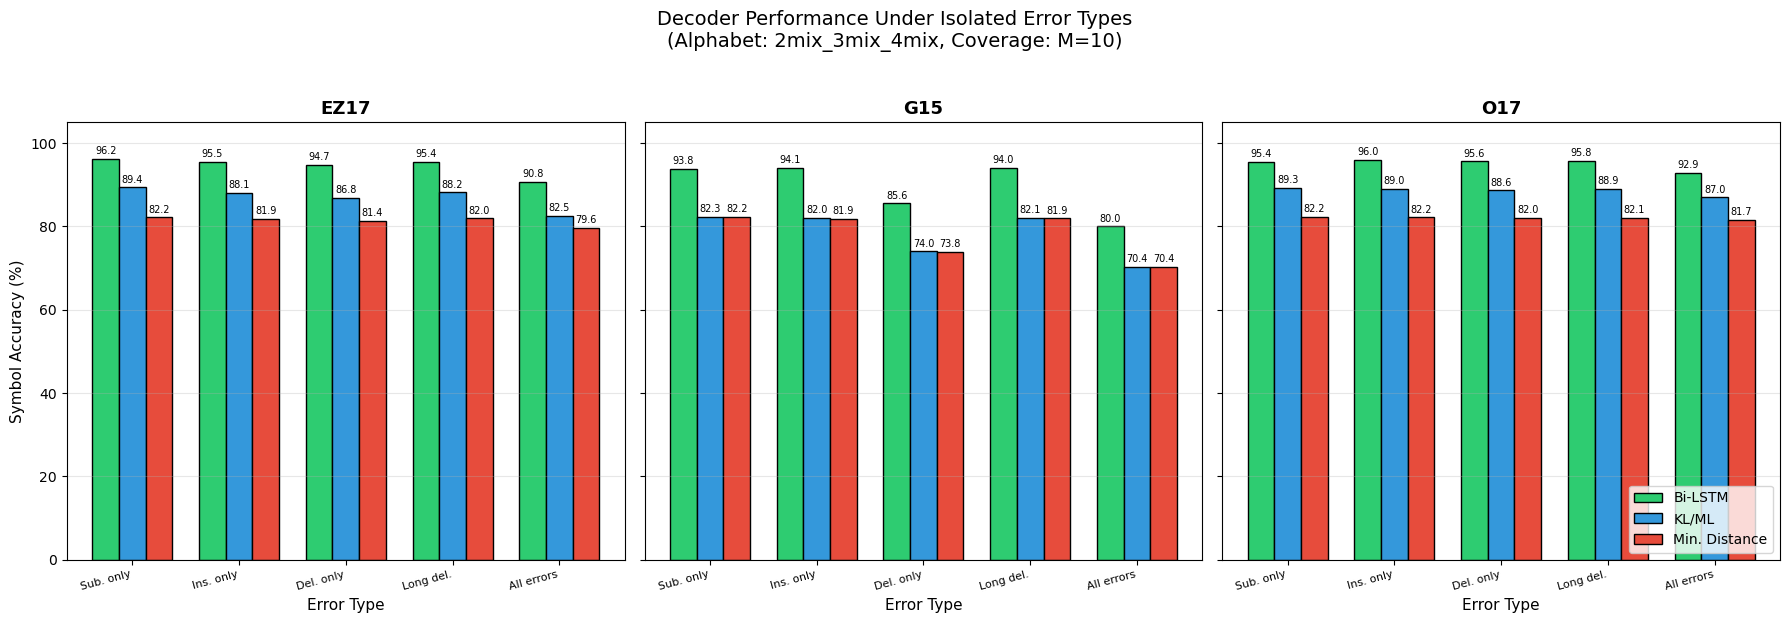

Figure saved: ./isolated_error_analysis/2mix_3mix_4mix_H128_L2_lr1e-03_seed42_M10/isolated_error_analysis_all_models.png


In [21]:
# =============================================================================
# CELL 21: VISUALIZATION -- GROUPED BAR CHART
# =============================================================================
print("=" * 70)
print(" GENERATING VISUALIZATION")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
error_types = [ERROR_MODE_SHORT[m] for m in ERROR_MODES]
colors = {'lstm': '#2ecc71', 'kl': '#3498db', 'mindist': '#e74c3c'}

for idx, error_model in enumerate(ERROR_MODELS_TO_ANALYZE):
    ax = axes[idx]
    error_name = ERROR_MODEL_SPECS[error_model]['name']
    model_results = all_results['results_by_model'][error_name]

    lstm_acc    = [model_results[m]['lstm']    for m in ERROR_MODES]
    kl_acc      = [model_results[m]['kl']      for m in ERROR_MODES]
    mindist_acc = [model_results[m]['mindist'] for m in ERROR_MODES]

    x = np.arange(len(error_types))
    width = 0.25
    bars1 = ax.bar(x - width, lstm_acc,    width, label='Bi-LSTM',
                   color=colors['lstm'], edgecolor='black')
    bars2 = ax.bar(x,         kl_acc,      width, label='KL/ML',
                   color=colors['kl'], edgecolor='black')
    bars3 = ax.bar(x + width, mindist_acc, width, label='Min. Distance',
                   color=colors['mindist'], edgecolor='black')

    for bars in (bars1, bars2, bars3):
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f'{h:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 2), textcoords="offset points",
                        ha='center', va='bottom', fontsize=7)

    ax.set_xlabel('Error Type', fontsize=11)
    if idx == 0:
        ax.set_ylabel('Symbol Accuracy (%)', fontsize=11)
    ax.set_title(error_name, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(error_types, fontsize=8, rotation=15, ha='right')
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3, axis='y')
    if idx == 2:
        ax.legend(fontsize=10, loc='lower right')

plt.suptitle(f'Decoder Performance Under Isolated Error Types\n'
             f'(Alphabet: {BASE_CONFIG["alphabet_mode"]}, Coverage: M={COVERAGE_M})',
             fontsize=14, y=1.03)
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "isolated_error_analysis_all_models.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Figure saved: {fig_path}")

## Cell 22 — Additional analysis

In [22]:
# =============================================================================
# CELL 22: ADDITIONAL ANALYSIS
# =============================================================================
print("=" * 70)
print(" ADDITIONAL ANALYSIS")
print("=" * 70)

# 1. Bi-LSTM advantage over KL/ML.
print("\n1. Bi-LSTM advantage over KL/ML (percentage points):")
print(f"   {'Error Type':<22}", end="")
for m in [ERROR_MODEL_SPECS[em]['name'] for em in ERROR_MODELS_TO_ANALYZE]:
    print(f" {m:>8}", end="")
print(f" {'Mean':>8}")
print(f"   {'-'*60}")

all_advantages = []
for error_mode in ERROR_MODES:
    label = ERROR_MODE_LABELS[error_mode]
    print(f"   {label:<22}", end="")
    mode_advantages = []
    for error_model in ERROR_MODELS_TO_ANALYZE:
        error_name = ERROR_MODEL_SPECS[error_model]['name']
        acc = all_results['results_by_model'][error_name][error_mode]
        adv = acc['lstm'] - acc['kl']
        mode_advantages.append(adv)
        all_advantages.append(adv)
        print(f" {adv:>+7.2f}", end="")
    print(f" {np.mean(mode_advantages):>+7.2f}")

print(f"\n   Overall mean advantage: "
      f"{np.mean(all_advantages):.2f} +/- {np.std(all_advantages):.2f} points")

# 2. Most damaging error type (drop from substitution-only Bi-LSTM accuracy).
print("\n2. Most damaging error type (Bi-LSTM accuracy drop vs substitutions):")
for error_model in ERROR_MODELS_TO_ANALYZE:
    error_name = ERROR_MODEL_SPECS[error_model]['name']
    mr = all_results['results_by_model'][error_name]
    sub_acc = mr['substitution_only']['lstm']
    drops = {
        'Insertions':     sub_acc - mr['insertion_only']['lstm'],
        'Deletions':      sub_acc - mr['deletion_only']['lstm'],
        'Long deletions': sub_acc - mr['long_deletion_only']['lstm'],
    }
    worst = max(drops, key=drops.get)
    print(f"   {error_name}: {worst} (drop: {drops[worst]:.2f}%)")

# 3. Error-model sensitivity (accuracy range across error types).
print("\n3. Error-model sensitivity (accuracy range across error types):")
for error_model in ERROR_MODELS_TO_ANALYZE:
    error_name = ERROR_MODEL_SPECS[error_model]['name']
    mr = all_results['results_by_model'][error_name]
    lstm_accs = [mr[m]['lstm'] for m in ERROR_MODES]
    kl_accs   = [mr[m]['kl']   for m in ERROR_MODES]
    print(f"   {error_name}: Bi-LSTM range={max(lstm_accs)-min(lstm_accs):.2f}%, "
          f"KL/ML range={max(kl_accs)-min(kl_accs):.2f}%")

 ADDITIONAL ANALYSIS

1. Bi-LSTM advantage over KL/ML (percentage points):
   Error Type                 EZ17      G15      O17     Mean
   ------------------------------------------------------------
   Substitutions only       +6.79  +11.49   +6.12   +8.13
   Insertions only          +7.44  +12.02   +7.01   +8.82
   Deletions only           +7.93  +11.52   +6.99   +8.82
   Long deletions only      +7.24  +11.95   +6.89   +8.69
   All errors (original)    +8.27   +9.65   +5.92   +7.95

   Overall mean advantage: 8.48 +/- 2.15 points

2. Most damaging error type (Bi-LSTM accuracy drop vs substitutions):
   EZ17: Deletions (drop: 1.45%)
   G15: Deletions (drop: 8.21%)
   O17: Deletions (drop: -0.21%)

3. Error-model sensitivity (accuracy range across error types):
   EZ17: Bi-LSTM range=5.41%, KL/ML range=6.88%
   G15: Bi-LSTM range=14.02%, KL/ML range=11.89%
   O17: Bi-LSTM range=3.16%, KL/ML range=2.36%


## Cell 23 — Summary

In [23]:
# =============================================================================
# CELL 23: SUMMARY
# =============================================================================
print("=" * 70)
print(" ISOLATED ERROR-TYPE ANALYSIS COMPLETE")
print("=" * 70)
print(f"\nConfiguration:")
print(f"   Alphabet : {BASE_CONFIG['alphabet_mode']} "
      f"({BASE_CONFIG['vocab_size']} classes)")
print(f"   Coverage : M={COVERAGE_M}")
print(f"   Models   : {[ERROR_MODEL_SPECS[m]['name'] for m in ERROR_MODELS_TO_ANALYZE]}")
print(f"   Noise    : corrected two-stage model (general coin + per-base "
      f"event weights) with long deletions")

print(f"\nKey findings:")
print(f"   1. Bi-LSTM advantage over KL/ML: "
      f"{np.mean(all_advantages):.2f} +/- {np.std(all_advantages):.2f} points")
print(f"   2. Advantage holds across all five isolated error modes and all "
      f"three error models")

print(f"\nOutput files:")
print(f"   Results JSON : {results_path}")
print(f"   LaTeX table  : {latex_path}")
print(f"   Figure       : {fig_path}")
print("=" * 70)

 ISOLATED ERROR-TYPE ANALYSIS COMPLETE

Configuration:
   Alphabet : 2mix_3mix_4mix (15 classes)
   Coverage : M=10
   Models   : ['EZ17', 'G15', 'O17']
   Noise    : corrected two-stage model (general coin + per-base event weights) with long deletions

Key findings:
   1. Bi-LSTM advantage over KL/ML: 8.48 +/- 2.15 points
   2. Advantage holds across all five isolated error modes and all three error models

Output files:
   Results JSON : ./isolated_error_analysis/2mix_3mix_4mix_H128_L2_lr1e-03_seed42_M10/isolated_error_analysis_all_models.json
   LaTeX table  : ./isolated_error_analysis/2mix_3mix_4mix_H128_L2_lr1e-03_seed42_M10/latex_table_isolated_errors.tex
   Figure       : ./isolated_error_analysis/2mix_3mix_4mix_H128_L2_lr1e-03_seed42_M10/isolated_error_analysis_all_models.png
